## **SINGLE SYSTEMS**

In [1]:
from qiskit import __version__
print(__version__)

2.3.1


In [2]:
import numpy as np 

ket0 = np.array([[1], [0]])
ket1 = np.array([[0], [1]])

print(ket0/2 + ket1/2)

[[0.5]
 [0.5]]


In [3]:
M1 = np.array([[1,1], [0,0]])
M2 = np.array([[1,0],[0,1]])
M = M1/2 + M2/2
print(M)

[[1.  0.5]
 [0.  0.5]]


In [4]:
#matriks multiplication
a = np.matmul(M1, ket1)         
b = np.matmul(M1, M2)
c = np.matmul(M, M)

print(a)
print(b)
print(c)

[[1]
 [0]]
[[1 1]
 [0 0]]
[[1.   0.75]
 [0.   0.25]]


In [5]:
from qiskit.visualization import array_to_latex

display(array_to_latex(a))
display(array_to_latex(b))
display(array_to_latex(c))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [6]:
from qiskit.quantum_info import Statevector

u = Statevector([1/np.sqrt(2), 1/np.sqrt(2)])
v = Statevector([(1+2.0j)/3, -2/3])
w = Statevector([1/3, 2/3])

In [7]:
display(u.draw('text'))
display(u.draw('latex'))
display(u.draw('latex_source'))

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

'\\frac{\\sqrt{2}}{2} |0\\rangle+\\frac{\\sqrt{2}}{2} |1\\rangle'

In [8]:
display(v.draw('text'))
display(v.draw('latex'))
display(v.draw('latex_source'))

[ 0.33333333+0.66666667j,-0.66666667+0.j        ]

<IPython.core.display.Latex object>

'(\\frac{1}{3} + \\frac{2 i}{3}) |0\\rangle- \\frac{2}{3} |1\\rangle'

In [9]:
display(w.draw('text'))
display(w.draw('latex'))
display(w.draw('latex_source'))

[0.33333333+0.j,0.66666667+0.j]

<IPython.core.display.Latex object>

'\\frac{1}{3} |0\\rangle+\\frac{2}{3} |1\\rangle'

In [10]:
#which checks to see if a given vector is a valid quantum state vector
display(u.is_valid())
display(v.is_valid())
display(w.is_valid())

True

True

False

In [11]:
#simulating measureent using Statevector
display(v.draw('latex'))

<IPython.core.display.Latex object>

In [12]:
#mengembalikan hasil pengukuran, dan menambahkan vektor keadaan kuantum baru ke dalam sistem setelah pengukuran
outcome, state = v.measure()
print(f"Measured: {outcome}\nPost-measurement state:\n")
display(state.draw('latex'))        #hasilnya bakal beda2 setiap di run karena hasil pengukuran bersifat probabilistik

Measured: 0
Post-measurement state:



<IPython.core.display.Latex object>

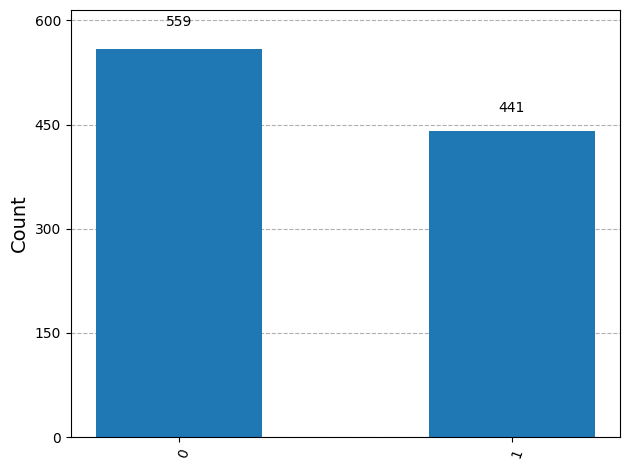

In [13]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(1000)
plot_histogram(statistics)

In [14]:
#mendefinisikan operator uniter pake oprator class dari qiskit
from qiskit.quantum_info import Operator

Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1/np.sqrt(2), 1/np.sqrt(2)], [1/np.sqrt(2), -1/np.sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j)/np.sqrt(2)]])

display(T.draw("latex"))

<IPython.core.display.Latex object>

In [15]:
#aplikasikan operator uniter ke state vector pake evolve metode
v = Statevector([1,0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)

display(v.draw('latex'))

<IPython.core.display.Latex object>

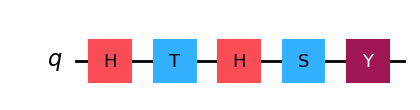

In [16]:
#menampilkan quantum circuit
from qiskit import QuantumCircuit
qc = QuantumCircuit(1)
qc.h(0)
qc.t(0)
qc.h(0)
qc.s(0)
qc.y(0)
display(qc.draw('mpl'))

In [17]:
#menampilkan quantum circuit pake latex
display(Operator.from_circuit(qc).draw('latex'))

<IPython.core.display.Latex object>

In [18]:
#menginisialisasi state vector kuantum awal dan kemudian mengembangkan keadaan sesuai dengan urutan operator yang diberikan dalam quantum circuit
ket0 = Statevector([1,0])
v = ket0.evolve(qc)
display(v.draw('latex'))

<IPython.core.display.Latex object>

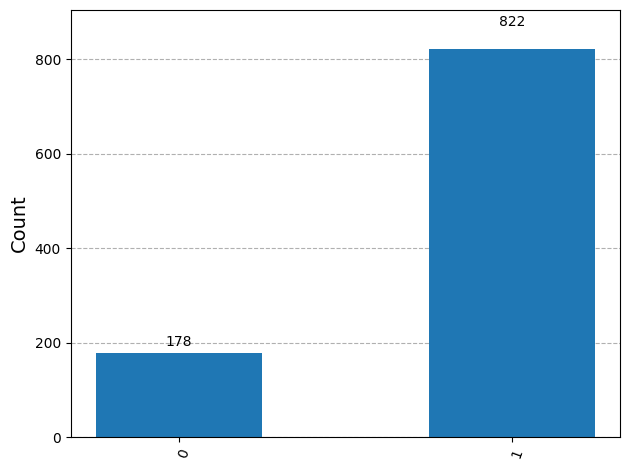

In [19]:
statistics = v.sample_counts(1000)
plot_histogram(statistics)

## **MULTIPLE SYSTEM**

In [20]:
from qiskit.quantum_info import Statevector, Operator
import numpy as np

### ***tensor product***

In [21]:
zero = Statevector.from_label('0')
one = Statevector.from_label('1')
psi = zero.tensor(one)
display(psi.draw('latex'))

<IPython.core.display.Latex object>

In [22]:
plus = Statevector.from_label('+')
minus_i = Statevector.from_label('l')
phi = plus.tensor(minus_i)
display(phi.draw('latex'))

<IPython.core.display.Latex object>

In [23]:
#bisa pake ^ buat tensor product juga
display((plus ^ minus_i).draw('latex'))

<IPython.core.display.Latex object>

In [24]:
#operator juga punya metode tensor product
H = Operator.from_label('H')
Id = Operator.from_label('I')
X = Operator.from_label('X')
Y = Operator.from_label('Y')
Z = Operator.from_label('Z')

display(H.tensor(Id).draw('latex'))
display(H.tensor(Id).tensor(X).draw('latex'))
display(H.tensor(Id).tensor(Y).draw('latex'))
display(H.tensor(Id).tensor(Z).draw('latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [25]:
display((H^Id^X).draw('latex'))

<IPython.core.display.Latex object>

In [26]:
display((phi.evolve(H^Id).draw('latex')))

<IPython.core.display.Latex object>

In [27]:
#kode yg sama, tapi pake CX operator dan menghitung CX|PSI> untuk |PSI> = |+>^|0>. Jelasnya, CX qubit kiri adalah kontrol dan qubit kanan adalah target
CX = Operator([[1,0,0,0], [0,1,0,0], [0,0,0,1], [0,0,1,0]])
psi = (plus ^ zero)
display(psi.evolve(CX).draw('latex'))

<IPython.core.display.Latex object>

#### ***partial measurement***
secara default, mengukur semua state qubit vector. Sebagai alternatif, dapat memberikan daftar bilangan ulat sebagai argumen, yang hanya menyebabkan indeks qubit tersebut diukur. sehingga, menciptakan keadaan:

In [28]:
w = Statevector([0,1,1,0,1,0,0,0]/np.sqrt(3))
display(w.draw('latex'))

result, state = w.measure([0])
print(f"Measured: {result}\nState after measurement:")
display(state.draw('latex'))

result, state = w.measure([0,1])
print(f"Measured: {result}\nState after measurement:")
display(state.draw('latex'))

<IPython.core.display.Latex object>

Measured: 0
State after measurement:


<IPython.core.display.Latex object>

Measured: 00
State after measurement:


<IPython.core.display.Latex object>

## **ENTANGLEMENT IN ACTION**

#### ***protocol teleportation***

In [29]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

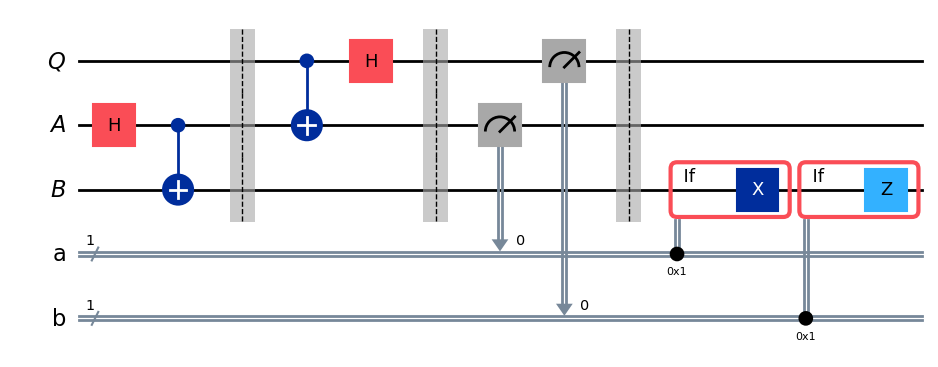

In [30]:
#implementasi quantum circuit untuk protocol teleportasi kuantum, yang memungkinkan untuk mentransfer keadaan kuantum dari satu lokasi ke lokasi lain tanpa memindahkan partikel fisik yang membawa keadaan tersebut.
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

#menyiapkan ebit untuk teleportasi
protocol.h(ebit0[0])
protocol.cx(ebit0, ebit1)
protocol.barrier()

#operator alice
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()

#pengukuran alice dan mengirim hasilnya ke bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

#bob melakukan operasi koreksi berdasarkan hasil pengukuran alice
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

display(protocol.draw('mpl'))

Circuit pertama kali menginisialisasi (A,B) untuk berada di keadaan $ |\phi+> $ (yang dimana bukan bagian dari protocol), mengikuti pengukuran operator Alice, dan terakhir operator Bob. untuk menguji apakah protocol bekerja dengan benar, kita mengaplikasikan single qubit gate untuk menginisialisasi $ |0> $ state of Q untuk mendapatkan random quantum state vector to be telported. dengan mengaplikasikan invers (conjugate transpose) of that gate to B setelah protocolnya berjalan. kita dapan memverifikasi keadaanya sudah teleportasi dengan pengukuran dan melihat apakah sudah berganti ke $ |0> $ state

In [31]:
#pertama, randomly memilih unitary qubit gate
random_gate = UGate(
    theta=random.random()*2*pi,
    phi=random.random()*2*pi,
    lam=random.random()*2*pi
)

display(array_to_latex(random_gate.to_matrix()))

<IPython.core.display.Latex object>

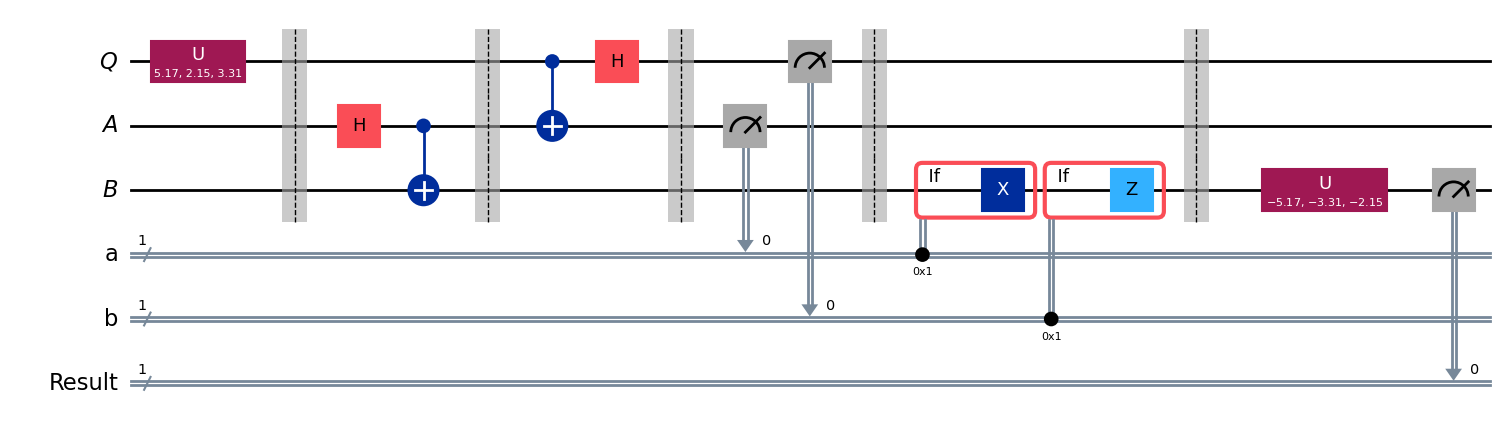

In [32]:
#membuat circuit baru yang terdapat bit dan qubit yang sama yang digunakan dalam protocol teleportasi
test = QuantumCircuit(qubit, ebit0, ebit1, a, b)

#memulai dengan randomly selected gate on Q
test.append(random_gate, qubit)
test.barrier()

#menambahkan seluruh protocol teleportasi dari atas ke circuit baru
test = test.compose(protocol)
test.barrier()

#akhirnya, mengaplikasikan inverse dari random uniter ke B dan pengukuran
test.append(random_gate.inverse(), ebit1)
result = ClassicalRegister(1, "Result")
test.add_register(result)
test.measure(ebit1, result)

display(test.draw('mpl'))

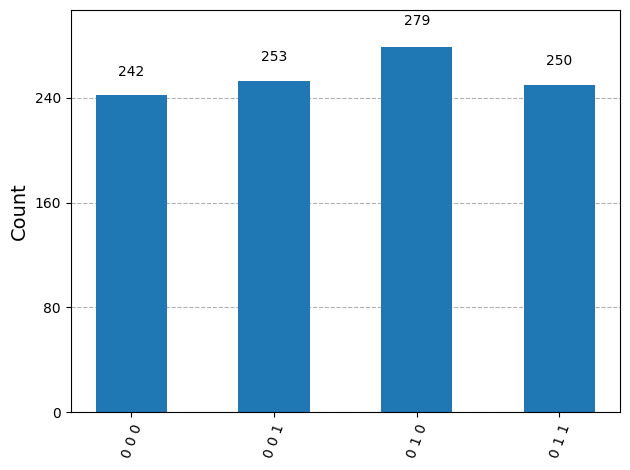

In [33]:
#terakhir, jalankan Aer simulator pada circuit dan plot histogram dari output
result = AerSimulator().run(test).result()
statistics = result.get_counts()
plot_histogram(statistics)

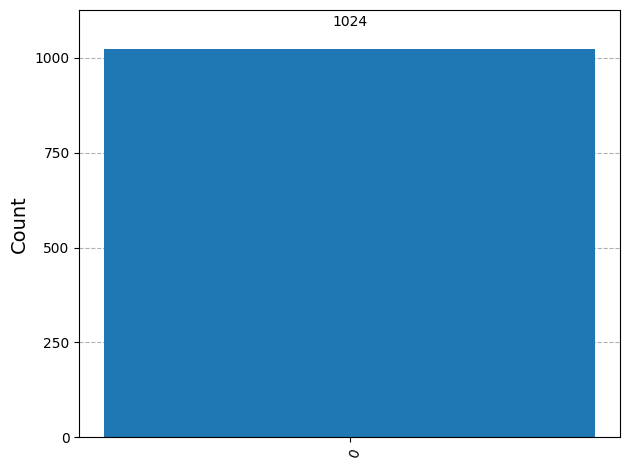

In [34]:
#dapat difilter agar terfous pada hasil tes qubit yang diinginkan
filtered_stats = marginal_distribution(statistics, [2])
plot_histogram(filtered_stats)

#### ***superdense coding***

superdense coding adalah protocol yang terkadang mencapai tujuan komplementer untuk teleportasi. daripada mengizinkan transmisi satu qubit menggunakan dua bit klasit (dengan keterlibatan 1 ebit), memungkinkan transmisi dua bit klasik menggunakan satu qubit kuantum (dengan keterlibatan 1 ebit) 

detailnya, pengirim (Alice) dan penerima (Bob) memberikan keterlibatan 1 ebit. according to the conventions in place for the lesson, artinya Alice memegang qubit A dan Bob memegang qubit B. Alice ingin mengirim 2 classical bit ke Bob, yang akan dikerjakan dengan c dan d, dan Alice akan mencapai ini dengan mengirimkan Bob 1 qubit.

superdense coding terlihat kurang menarik dibandingkan teleportasi kuantum. karena superdensi coding memberikan contoh nyata dan jelas tentang bagaimana **entanglement** bisa digunakan secara praktis untuk meningkatkan kemampuan komunikasi. ada sebuah teorema, yaitu ***teorema holevo*** yang dikembangkan oleh Alexander Holevo. Teorema ini menyataka bahwa tanpa adanya keadaan terjerat yang dibagikan sebelumnya antara pengirim dan penerima, satu qubit tidak bisa membawa lebih dari 1 bit informasi klasik. Artinya, terdapat batasan alami pada kapasitas informasi qubit jika tidak ada entaglement.

dengan superdense coding ini, batasan tersebut dapat diatasi dengan memanfaatkan entanglement. Hasilnya, satu qubit yang dikirim bisa membawa dua bit informasi klasik sekaligus. entanglement memungkinkan kapasitas pengiriman informasi klasik melalui wubit menjadi dua kali lipat dibandinhkan tanpa entanglement.

In [35]:
#implementasi sederhana dari superdense coding
c = "1"
d = "0"

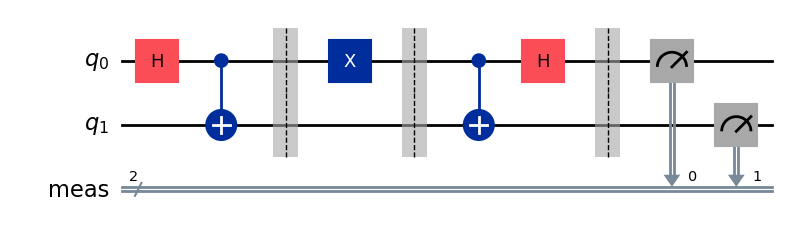

In [36]:
#membangun circuit untuk superdense coding
sc = QuantumCircuit(2)

#menyiapkan ebit untuk superdense coding
sc.h(0)
sc.cx(0, 1)
sc.barrier()

#operator alice
if d == "1":
    sc.z(0)
if c == "1":
    sc.x(0)
sc.barrier()

#bob melakukan operasi dekoding untuk mendapatkan kembali bit klasik yang dikirimkan oleh alice
sc.cx(0, 1) 
sc.h(0)
sc.measure_all()

display(sc.draw('mpl'))

Measured 10 with frequency 1024


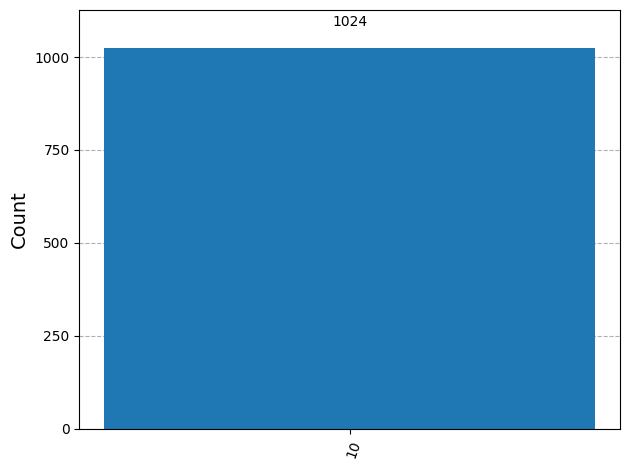

In [37]:
#menjalankan circuit pada simulator dan plot histogram dari output
result = AerSimulator().run(sc).result()
statistics = result.get_counts()

for outcome, frequency in statistics.items():
    print(f"Measured {outcome} with frequency {frequency}")

plot_histogram(statistics)

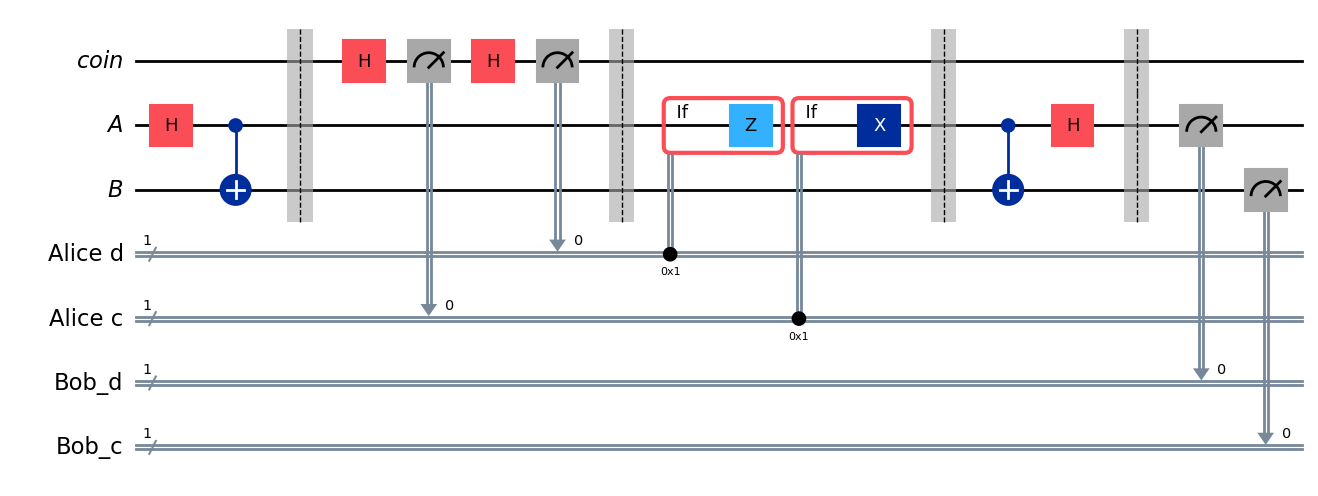

In [38]:
#memakai qubit tambahan sebagai sebagai random bit generator (dasar untuk membalik koin dengan adil)
rbg = QuantumRegister(1, "coin")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")

Alice_c = ClassicalRegister(1, "Alice c")
Alice_d = ClassicalRegister(1, "Alice d")

test = QuantumCircuit(rbg, ebit0, ebit1, Alice_d, Alice_c)

#menginisialisasi ebit
test.h(ebit0)
test.cx(ebit0, ebit1)
test.barrier()

#memakai "coin" qubit dua kali untuk geneterate alice bit c dan d
test.h(rbg)
test.measure(rbg, Alice_c)
test.h(rbg)
test.measure(rbg, Alice_d)
test.barrier()

#sekarang jalankan protocol
#dimulai dengan operator alice, yang bergantung pada bitnya
with test.if_test((Alice_d, 1), label = "Z"):
    test.z(ebit0)
with test.if_test((Alice_c, 1), label = "X"):
    test.x(ebit0)
test.barrier()

#bob melakukan operasi dekoding untuk mendapatkan kembali bit klasik yang dikirimkan oleh alice
test.cx(ebit0, ebit1)
test.h(ebit0)
test.barrier()

Bob_c = ClassicalRegister(1, "Bob_c")
Bob_d = ClassicalRegister(1, "Bob_d")
test.add_register(Bob_d)
test.add_register(Bob_c)
test.measure(ebit0, Bob_d)
test.measure(ebit1, Bob_c)

display(test.draw('mpl'))

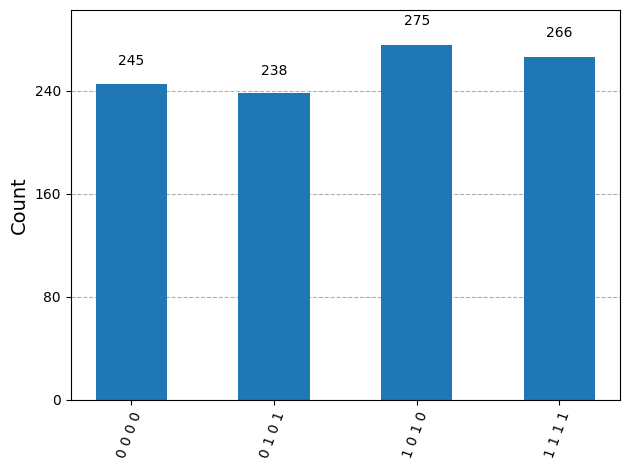

In [39]:
#menjalankan aer simulator pada circuit dan plot histogram dari output
result = AerSimulator().run(test).result()
statistics = result.get_counts()
plot_histogram(statistics)

#### ***The CHSH game***

dikenal sebagai ***nonlocal games***. nonlocak gaes sangat menarik dan memiliki hubungan yang dalam dengan fisika, ilkomp, dan matematika. nonlocal game adalah game koperatif yang terdapat 2 player (alice dan bob) bekerja sama untuk mencapai output tertentu.

In [40]:
#implementasi CHSH game bersamaan dengan strategi quantum dalam qiskit
#pertama, mendefinisikan game itu sendiri yang akan dipakai sebagai argumen

def chsh_game(startegy):
    #fungsi ini menjalankan CHSH game dengan strategi(fungsi a dari 2 bit ke 2 bit)
    #mengembalikan 1 jika menang dan 0 jika kalah

    #memilih x dan y secara acak
    x, y = random.randint(0, 1), random.randint(0, 1)

    #memakai strategi untuk mendapatkan a dan b
    a, b = startegy(x, y)

    #menentukan jika strategi menang atau kalah
    if (a != b) == (x & y):
        return 1    #win
    return 0        #lose

In [41]:
#sekarang membuat fungsi yang output circuitnya tergantung pada pertanyaan alice dan bob
#membiarkan qubit memiliki default names untuk penyederhanaan, dan akan dipakai untuk membuat
#gerbang Ry(theta) untuk alice dan bob

def chsh_circuit(x, y):
    #berfungsi untuk membuat quantum circuit untuk strategi CHSH tertentu
    qc = QuantumCircuit(2, 2)

    #menyiapkan ebit untuk strategi CHSH
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()

    #operator Alice
    if x == 1:
        qc.ry(0, 0)
    else:
        qc.ry(-pi/2, 0)
    qc.measure(0, 0)

    #operator Bob
    if y == 0:
        qc.ry(-pi/4, 1)
    else:
        qc.ry(pi/4, 1)
    qc.measure(1, 1)
    return qc

(x, y) = (0, 0)


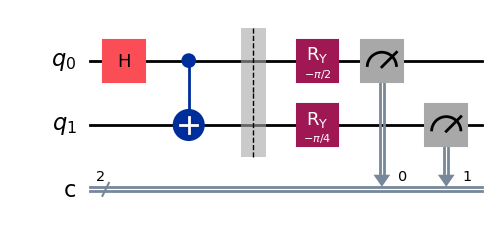

(x, y) = (0, 1)


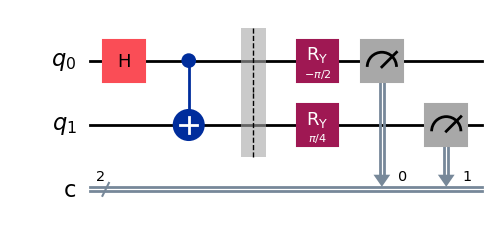

(x, y) = (1, 0)


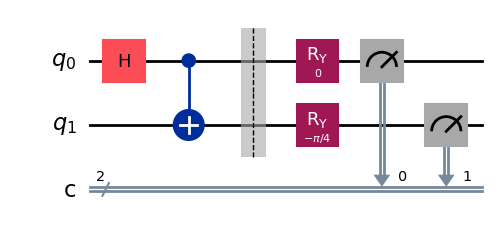

(x, y) = (1, 1)


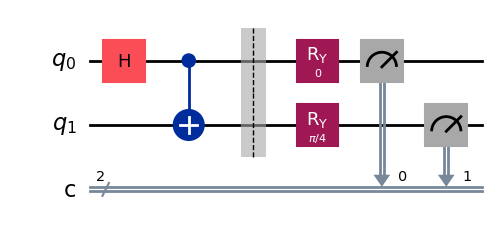

In [42]:
#draw teh four possible circuits for the different combinations of x and y

print("(x, y) = (0, 0)")
display(chsh_circuit(0, 0).draw('mpl'))

print("(x, y) = (0, 1)")
display(chsh_circuit(0, 1).draw('mpl'))

print("(x, y) = (1, 0)")
display(chsh_circuit(1, 0).draw('mpl'))

print("(x, y) = (1, 1)")
display(chsh_circuit(1, 1).draw('mpl'))

In [43]:
#memakai aer simulator yang akan berjalan pada circuit setiap waktu untuk memberikan fair input (x,y)
def quantum_strategy(x, y):
    #berfungsi untuk menjalankan quantum circuit dalam satu waktu dan mengembalikan hasil pengukuran sebagai output strategi

    #mengatur "shots = 1" untuk menjalankan circuit hanya sekali
    result = AerSimulator().run(chsh_circuit(x, y), shots=1).result()
    statistics = result.get_counts()

    #menentukan keluaran bit dan mengembalikannya
    bits = list(statistics.keys())[0]
    a, b = bits[0], bits[1]
    return a, b

In [44]:
#terakhir, memainkan game sebanyak 1000 kali dan menghitung fraksi kemenangan strategi quantum
NUM_GAMES = 1000
TOTAL_SCORE = 0

for _ in range(NUM_GAMES):
    TOTAL_SCORE += chsh_game(quantum_strategy)

print("Fraction of games won:", TOTAL_SCORE/NUM_GAMES)

Fraction of games won: 0.503


In [45]:
#kita juga dapat menentukan clasical startegi dan melihat bagaimana itu bekerja
#hanya 1 strategi, yang lain dapat di uji dengan mengganti code. tetapi ini adalah salah satu strategi
#klasik yang optimal

def classical_strategy(x, y):
    #berfungsi untuk mengimplementasikan satu contoh dari optimal classical dengan merubah nilai
    #bit tertulis untuk a dan b

    #jawaban Alice
    if x == 0:
        a = 0
    elif x == 1:
        a = 1

    #jawaban Bob
    if y == 0:
        b = 1
    elif y == 1:
        b = 0
    return a, b

In [46]:
#memainkan game sebanyak 1000 kali lagi
NUM_GAMES = 1000
TOTAL_SCORE = 0

for _ in range(NUM_GAMES):
    TOTAL_SCORE += chsh_game(classical_strategy)

print("Fraction of games won:", TOTAL_SCORE/NUM_GAMES)

Fraction of games won: 0.74
